# Exploratory Data Analysis — IN6227 Assignment 1, Variant 1

## Objective

Explore the training data to support justified preprocessing and
classification decisions.

The target is `label`, where `no = 0` and `yes = 1`.

## Questions

1. What are the dataset dimensions and feature types?
2. Which features contain missing values?
3. Are there duplicate records or conflicting labels?
4. Is the target imbalanced?
5. Which numerical features are skewed or contain extreme observations?
6. Are there rare or dominant categorical values?
7. Which features are associated with the target?
8. What preprocessing decisions are supported by these observations?

## Analysis boundaries

- Only the supplied training set is explored.
- The test set is reserved for final evaluation.
- Missing targets are excluded from supervised exploration.
- Missing feature values are retained during EDA.
- Outliers and zero values are inspected, not automatically removed.
- Associations are descriptive and do not establish causation.
- Imputation, scaling and encoding must be fitted within each
  cross-validation training fold in the modeling pipeline.

## Analysis populations

- Structural and data-quality checks use all training rows.
- Feature distributions and target comparisons use rows with valid labels.

In [26]:
%pip install numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Cell 3 — Code：导入库和设置

In [27]:
#Cell 3 — Code：导入库和设置

from importlib.metadata import version
import hashlib
import json
import math
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

LABEL_ORDER = ["no", "yes"]

PALETTE = {
    "no": "#4C78A8",
    "yes": "#F58518",
}

print("Python:", platform.python_version())

for package in ["numpy", "pandas", "matplotlib", "seaborn"]:
    print(f"{package}: {version(package)}")

Python: 3.10.1
numpy: 2.2.6
pandas: 2.3.3
matplotlib: 3.10.9
seaborn: 0.13.2


Cell 4 定位项目目录

In [28]:
from pathlib import Path


# 直接指定你的项目目录
PROJECT_ROOT_OVERRIDE = Path(
    r"F:\NTU Python\IN6227\IN6227-Assignment-1"
)


if PROJECT_ROOT_OVERRIDE is not None:
    PROJECT_ROOT = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
else:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    PROJECT_ROOT = next(
        (
            folder
            for folder in candidates
            if (folder / "data" / "train.csv").is_file()
        ),
        None,
    )

    if PROJECT_ROOT is None:
        raise FileNotFoundError(
            "无法找到 data/train.csv。"
            "请检查目录结构，或设置 PROJECT_ROOT_OVERRIDE。"
        )

TRAIN_PATH = PROJECT_ROOT / "data" / "train.csv"

if not TRAIN_PATH.is_file():
    raise FileNotFoundError(f"训练文件不存在：{TRAIN_PATH}")

EDA_DIR = PROJECT_ROOT / "outputs" / "eda"
FIGURE_DIR = EDA_DIR / "figures"
TABLE_DIR = EDA_DIR / "tables"

for folder in [EDA_DIR, FIGURE_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def save_table(table, filename, index=True):
    path = TABLE_DIR / filename
    table.to_csv(path, index=index, encoding="utf-8-sig")


def finish_figure(fig, filename):
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"{filename}.png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.show()
    plt.close(fig)


print("Project root:", PROJECT_ROOT)
print("Training file:", TRAIN_PATH)
print("EDA output:", EDA_DIR)

Project root: F:\NTU Python\IN6227\IN6227-Assignment-1
Training file: F:\NTU Python\IN6227\IN6227-Assignment-1\data\train.csv
EDA output: F:\NTU Python\IN6227\IN6227-Assignment-1\outputs\eda


In [29]:
TARGET = "label"

NUMERIC_COLS = [
    "aptitude_score",
    "performance_score",
    "stability_index",
    "load_ratio",
    "index_weight",
    "activity_duration",
    "composite_rank",
]

CATEGORICAL_COLS = [
    "geological_era",
    "weather_pattern",
    "region",
    "personal_interest",
    "brew_preference",
    "instrument",
    "species",
    "mineral_type",
]

FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS
EXPECTED_COLS = FEATURE_COLS + [TARGET]

# 全部先读为字符串，避免自动推断改变类别值。
raw = pd.read_csv(
    TRAIN_PATH,
    dtype="string",
    keep_default_na=False,
    encoding="utf-8-sig",
)

if raw.empty:
    raise ValueError("train.csv 没有数据行。")

raw.columns = raw.columns.str.strip()

if raw.columns.duplicated().any():
    raise ValueError("清理列名空格后出现重复列名。")

missing_columns = sorted(set(EXPECTED_COLS) - set(raw.columns))
unexpected_columns = sorted(set(raw.columns) - set(EXPECTED_COLS))

if missing_columns or unexpected_columns:
    raise ValueError(
        f"字段与预期不一致。\n"
        f"缺少字段：{missing_columns}\n"
        f"额外字段：{unexpected_columns}"
    )

# 工作副本：保留 raw 用于追踪读取内容。
df = raw.copy()

normalization_rows = []

for col in EXPECTED_COLS:
    original = df[col]
    stripped = original.str.strip()

    normalization_rows.append({
        "feature": col,
        "whitespace_trimmed": int(
            original.ne(stripped).fillna(False).sum()
        ),
        "blank_to_missing": int(
            stripped.eq("").fillna(False).sum()
        ),
    })

    df[col] = stripped.replace("", pd.NA)

# 检查非法数值文本，不能静默转换后当成普通缺失。
numeric_parse_issues = []

for col in NUMERIC_COLS:
    parsed = pd.to_numeric(df[col], errors="coerce")
    invalid = df[col].notna() & parsed.isna()

    if invalid.any():
        numeric_parse_issues.append({
            "feature": col,
            "count": int(invalid.sum()),
            "examples": df.loc[invalid, col].unique().tolist()[:10],
        })

    df[col] = parsed.astype("float64")

if numeric_parse_issues:
    display(pd.DataFrame(numeric_parse_issues))
    raise ValueError("发现无法解释的数值文本，请先核对原始数据。")

infinite_counts = pd.Series(
    np.isinf(df[NUMERIC_COLS].to_numpy()).sum(axis=0),
    index=NUMERIC_COLS,
)

if infinite_counts.sum() > 0:
    display(infinite_counts[infinite_counts > 0])
    raise ValueError("发现正负无穷值，请先核对来源。")

invalid_labels = (
    df[TARGET].notna()
    & ~df[TARGET].isin(LABEL_ORDER)
)

if invalid_labels.any():
    display(df.loc[invalid_labels, [TARGET]])
    raise ValueError("发现 no/yes 以外的非空标签，请先核对。")

normalization_table = pd.DataFrame(normalization_rows)
save_table(normalization_table, "normalization_log.csv", index=False)

print("Loaded shape:", df.shape)
display(df.head())
display(normalization_table)

Loaded shape: (31112, 16)


,geological_era,weather_pattern,region,aptitude_score,performance_score,stability_index,personal_interest,load_ratio,brew_preference,instrument,species,index_weight,mineral_type,activity_duration,composite_rank,label
0,Triassic,Heatwave,Texas,325.5800,34.9500,1.5030,Foraging,23.8780,Espresso,Dulcimer,Lynx,8.6300,Marble,77.9800,2.0930,no
1,Triassic,Monsoon,Texas,333.6300,256.5000,3.2830,Falconry,28.6170,Espresso,Cello,Bison,14.2200,Opal,95.7600,3.0280,no
2,Triassic,Monsoon,Texas,503.9600,385.0000,3.6760,Astronomy,22.5820,Espresso,Cello,Lynx,11.0400,Diamond,114.0300,4.5640,yes
3,Triassic,Heatwave,Texas,404.6100,156.4400,2.8120,Calligraphy,28.0020,Latte,Oboe,Lynx,15.6400,Sapphire,113.5800,3.0530,no
4,Triassic,Heatwave,Texas,358.8900,144.0500,2.7350,Beekeeping,22.0620,Espresso,Oboe,Lynx,10.9900,Granite,79.4000,2.7300,no


,feature,whitespace_trimmed,blank_to_missing
0,aptitude_score,0,4
1,performance_score,0,2
2,stability_index,0,2
3,load_ratio,0,2
4,index_weight,0,3
5,activity_duration,0,2
6,composite_rank,0,1
7,geological_era,0,2
8,weather_pattern,0,3
9,region,0,4


In [30]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_missing": df.notna().sum(),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_non_missing": df.nunique(dropna=True),
})

overview["role"] = [
    "target" if col == TARGET
    else "numerical" if col in NUMERIC_COLS
    else "categorical"
    for col in overview.index
]

display(overview)

print(f"Rows: {len(df):,}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Numerical features: {len(NUMERIC_COLS)}")
print(f"Categorical features: {len(CATEGORICAL_COLS)}")
print(
    "Memory usage:",
    f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB",
)

save_table(overview, "data_overview.csv")

,dtype,non_missing,missing_count,missing_pct,unique_non_missing,role
geological_era,string,31110,2,0.0064,5,categorical
weather_pattern,string,31109,3,0.0096,7,categorical
region,string,31108,4,0.0129,21,categorical
aptitude_score,float64,31108,4,0.0129,15148,numerical
performance_score,float64,31110,2,0.0064,24418,numerical
stability_index,float64,31110,2,0.0064,3788,numerical
personal_interest,string,31106,6,0.0193,11,categorical
load_ratio,float64,31110,2,0.0064,18799,numerical
brew_preference,string,31105,7,0.0225,2,categorical
instrument,string,31109,3,0.0096,6,categorical


Rows: 31,112
Features: 15
Numerical features: 7
Categorical features: 8
Memory usage: 18.49 MB


,missing_count,missing_pct
brew_preference,7,0.0225
personal_interest,6,0.0193
region,4,0.0129
aptitude_score,4,0.0129
index_weight,3,0.0096
species,3,0.0096
instrument,3,0.0096
weather_pattern,3,0.0096
mineral_type,3,0.0096
label,3,0.0096


,row_count
missing_features_per_row,
0,31065
1,47


Rows with at least one missing feature: 47
Rows with missing targets: 3


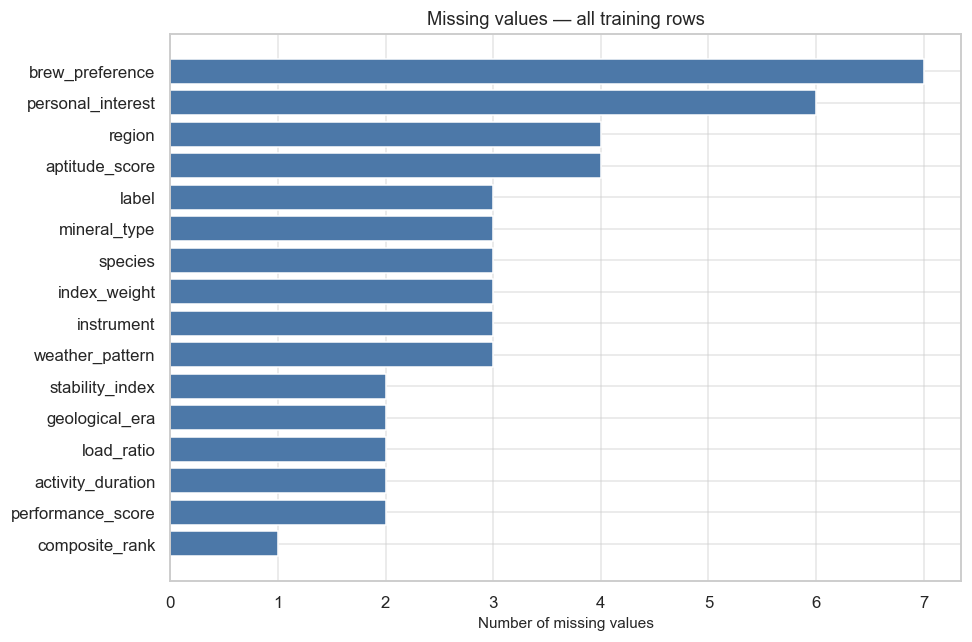

In [31]:
# Cell 7 缺失值分析
# 除了每列缺失数，也检查每行有多少个特征缺失。

missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
}).sort_values("missing_count", ascending=False)

row_missing_counts = df[FEATURE_COLS].isna().sum(axis=1)

row_missing_table = (
    row_missing_counts.value_counts()
    .sort_index()
    .rename_axis("missing_features_per_row")
    .to_frame("row_count")
)

display(missing_table)
display(row_missing_table)

print(
    "Rows with at least one missing feature:",
    int(row_missing_counts.gt(0).sum()),
)
print("Rows with missing targets:", int(df[TARGET].isna().sum()))

plot_data = (
    missing_table.loc[missing_table["missing_count"] > 0]
    .sort_values("missing_count")
)

if not plot_data.empty:
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.barh(
        plot_data.index,
        plot_data["missing_count"],
        color="#4C78A8",
    )

    ax.set_title("Missing values — all training rows")
    ax.set_xlabel("Number of missing values")

    finish_figure(fig, "01_missing_values")
else:
    print("No missing values found.")

save_table(missing_table, "missing_values.csv")
save_table(row_missing_table, "row_missing_counts.csv")

In [32]:
#Cell 8 重复记录与标签冲突
'''
区分三种情况：
- 完整行重复：特征和标签都一样。
- 特征重复：输入特征完全一样。
- 标签冲突：相同特征同时对应 no 和 yes。
不在 EDA 中自动删除这些记录。
'''


full_duplicates = int(df.duplicated().sum())
feature_duplicates = int(df.duplicated(subset=FEATURE_COLS).sum())

feature_duplicate_mask = df.duplicated(
    subset=FEATURE_COLS,
    keep=False,
)

duplicate_records = df.loc[feature_duplicate_mask].copy()

if duplicate_records.empty:
    conflicting_groups = pd.Series(
        dtype="int64",
        name="distinct_labels",
    )
else:
    distinct_labels = (
        duplicate_records
        .groupby(FEATURE_COLS, dropna=False)[TARGET]
        .nunique(dropna=True)
    )
    conflicting_groups = distinct_labels[distinct_labels > 1]

duplicate_summary = pd.DataFrame({
    "check": [
        "Full duplicate rows beyond first occurrence",
        "Duplicate feature rows beyond first occurrence",
        "Rows involved in duplicate feature groups",
        "Feature groups with conflicting observed labels",
    ],
    "count": [
        full_duplicates,
        feature_duplicates,
        int(feature_duplicate_mask.sum()),
        len(conflicting_groups),
    ],
})

display(duplicate_summary)

if not duplicate_records.empty:
    display(duplicate_records.head(20))
    save_table(
        duplicate_records,
        "duplicate_feature_records.csv",
        index=True,
    )

if not conflicting_groups.empty:
    display(conflicting_groups.head(20))

save_table(duplicate_summary, "duplicate_summary.csv", index=False)

,check,count
0,Full duplicate rows beyond first occurrence,0
1,Duplicate feature rows beyond first occurrence,0
2,Rows involved in duplicate feature groups,0
3,Feature groups with conflicting observed labels,0


In [33]:
#Cell 9 — Code：创建有效标签分析集
#之后的分布分析与标签比较使用 eda，不修改原始 df。

missing_target_mask = df[TARGET].isna()

excluded_target_rows = pd.DataFrame({
    # 从 0 开始的数据记录位置，不等同于文件的物理行号。
    "source_row_index": df.index[missing_target_mask],
    "reason": "missing_target",
})

eda = df.loc[~missing_target_mask].copy()

if eda.empty:
    raise ValueError("没有可用于监督分析的有效标签记录。")

if set(eda[TARGET].unique()) != set(LABEL_ORDER):
    raise ValueError("有效标签数据必须同时包含 no 和 yes。")

y = eda[TARGET].map({"no": 0, "yes": 1}).astype("int64")

print(f"All training rows: {len(df):,}")
print(f"Missing-target rows excluded: {missing_target_mask.sum():,}")
print(f"Labeled rows used for subsequent EDA: {len(eda):,}")

save_table(
    excluded_target_rows,
    "excluded_missing_target_rows.csv",
    index=False,
)

All training rows: 31,112
Missing-target rows excluded: 3
Labeled rows used for subsequent EDA: 31,109


,count,percentage
label,,
no,23645,76.0069
yes,7464,23.9931


Positive-class proportion: 23.99%
Majority/minority count ratio: 3.17
Always-majority accuracy on these rows: 76.01%
Constant-score AP reference on these labels: 0.2399


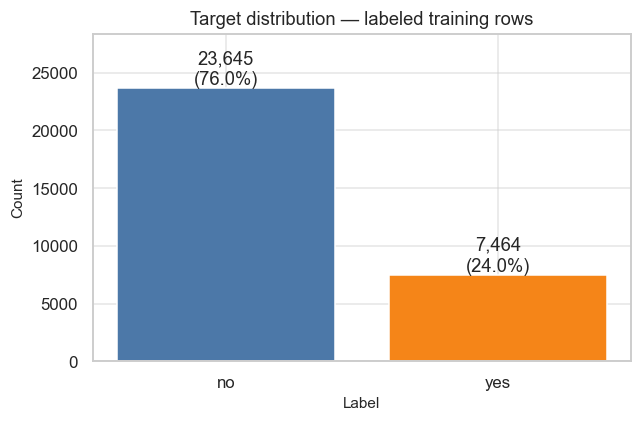

In [34]:
#Cell 10 — Code：类别不平衡分析
#输出多数类准确率参照，帮助解释为什么不能只看 accuracy。
#这里的 constant-score AP 是当前训练标签上的参照值，不是已经训练或交叉验证得到的模型结果。

class_counts = (
    eda[TARGET]
    .value_counts()
    .reindex(LABEL_ORDER, fill_value=0)
)

class_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_counts / len(eda) * 100,
})

positive_rate = float(y.mean())
majority_accuracy = float(class_counts.max() / len(eda))
imbalance_ratio = float(class_counts.max() / class_counts.min())

display(class_summary)

print(f"Positive-class proportion: {positive_rate:.2%}")
print(f"Majority/minority count ratio: {imbalance_ratio:.2f}")
print(f"Always-majority accuracy on these rows: {majority_accuracy:.2%}")
print(
    "Constant-score AP reference on these labels:",
    f"{positive_rate:.4f}",
)

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    LABEL_ORDER,
    class_counts.to_numpy(),
    color=[PALETTE[label] for label in LABEL_ORDER],
)

for bar, label in zip(bars, LABEL_ORDER):
    count = class_counts[label]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({count / len(eda):.1%})",
        ha="center",
        va="bottom",
    )

ax.set_ylim(0, class_counts.max() * 1.2)
ax.set_title("Target distribution — labeled training rows")
ax.set_xlabel("Label")
ax.set_ylabel("Count")

finish_figure(fig, "02_class_distribution")
save_table(class_summary, "class_distribution.csv")

In [35]:
#Cell 11 — Code：数值特征描述统计
'''重点关注：
- mean 与 50% 是否相差较大。
- max 与 99% 是否相距很远。
- skewness 是否提示明显偏斜。
- 零值和负值是否需要进一步核对。
负值或零值本身不代表数据错误。'''

numeric_summary = eda[NUMERIC_COLS].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T

numeric_summary["missing_count"] = eda[NUMERIC_COLS].isna().sum()
numeric_summary["skewness"] = eda[NUMERIC_COLS].skew()
numeric_summary["zero_count"] = eda[NUMERIC_COLS].eq(0).sum()
numeric_summary["negative_count"] = eda[NUMERIC_COLS].lt(0).sum()

display(numeric_summary)

save_table(numeric_summary, "numeric_summary.csv")

,count,mean,std,min,1%,25%,50%,75%,99%,max,missing_count,skewness,zero_count,negative_count
aptitude_score,31105.0000,342.1318,68.9262,90.0000,151.0116,310.5900,333.5100,402.5600,492.6556,510.0000,4,-0.2917,0,0
performance_score,31107.0000,296.4977,187.6276,0.0000,2.1236,146.5700,275.3900,420.1750,779.0588,1010.0000,2,0.5522,265,0
stability_index,31107.0000,3.1564,0.8493,0.0000,0.1923,2.7510,3.3510,3.7620,4.3680,4.6250,2,-1.2293,265,0
load_ratio,31107.0000,24.4233,9.9200,0.0000,3.5007,19.2720,23.6890,27.6570,59.1741,143.7170,2,1.7053,38,0
index_weight,31106.0000,12.7216,7.7472,0.0000,0.9300,7.5200,11.7300,16.2300,36.5895,99.6200,3,1.5114,4,0
activity_duration,31107.0000,80.3625,25.5142,0.0000,11.9306,72.7400,80.3300,90.2600,155.6816,205.0000,2,0.1994,38,0
composite_rank,31108.0000,3.2388,0.8698,0.5890,1.4420,2.5910,3.1990,3.8380,5.3499,6.8760,1,0.2575,0,0


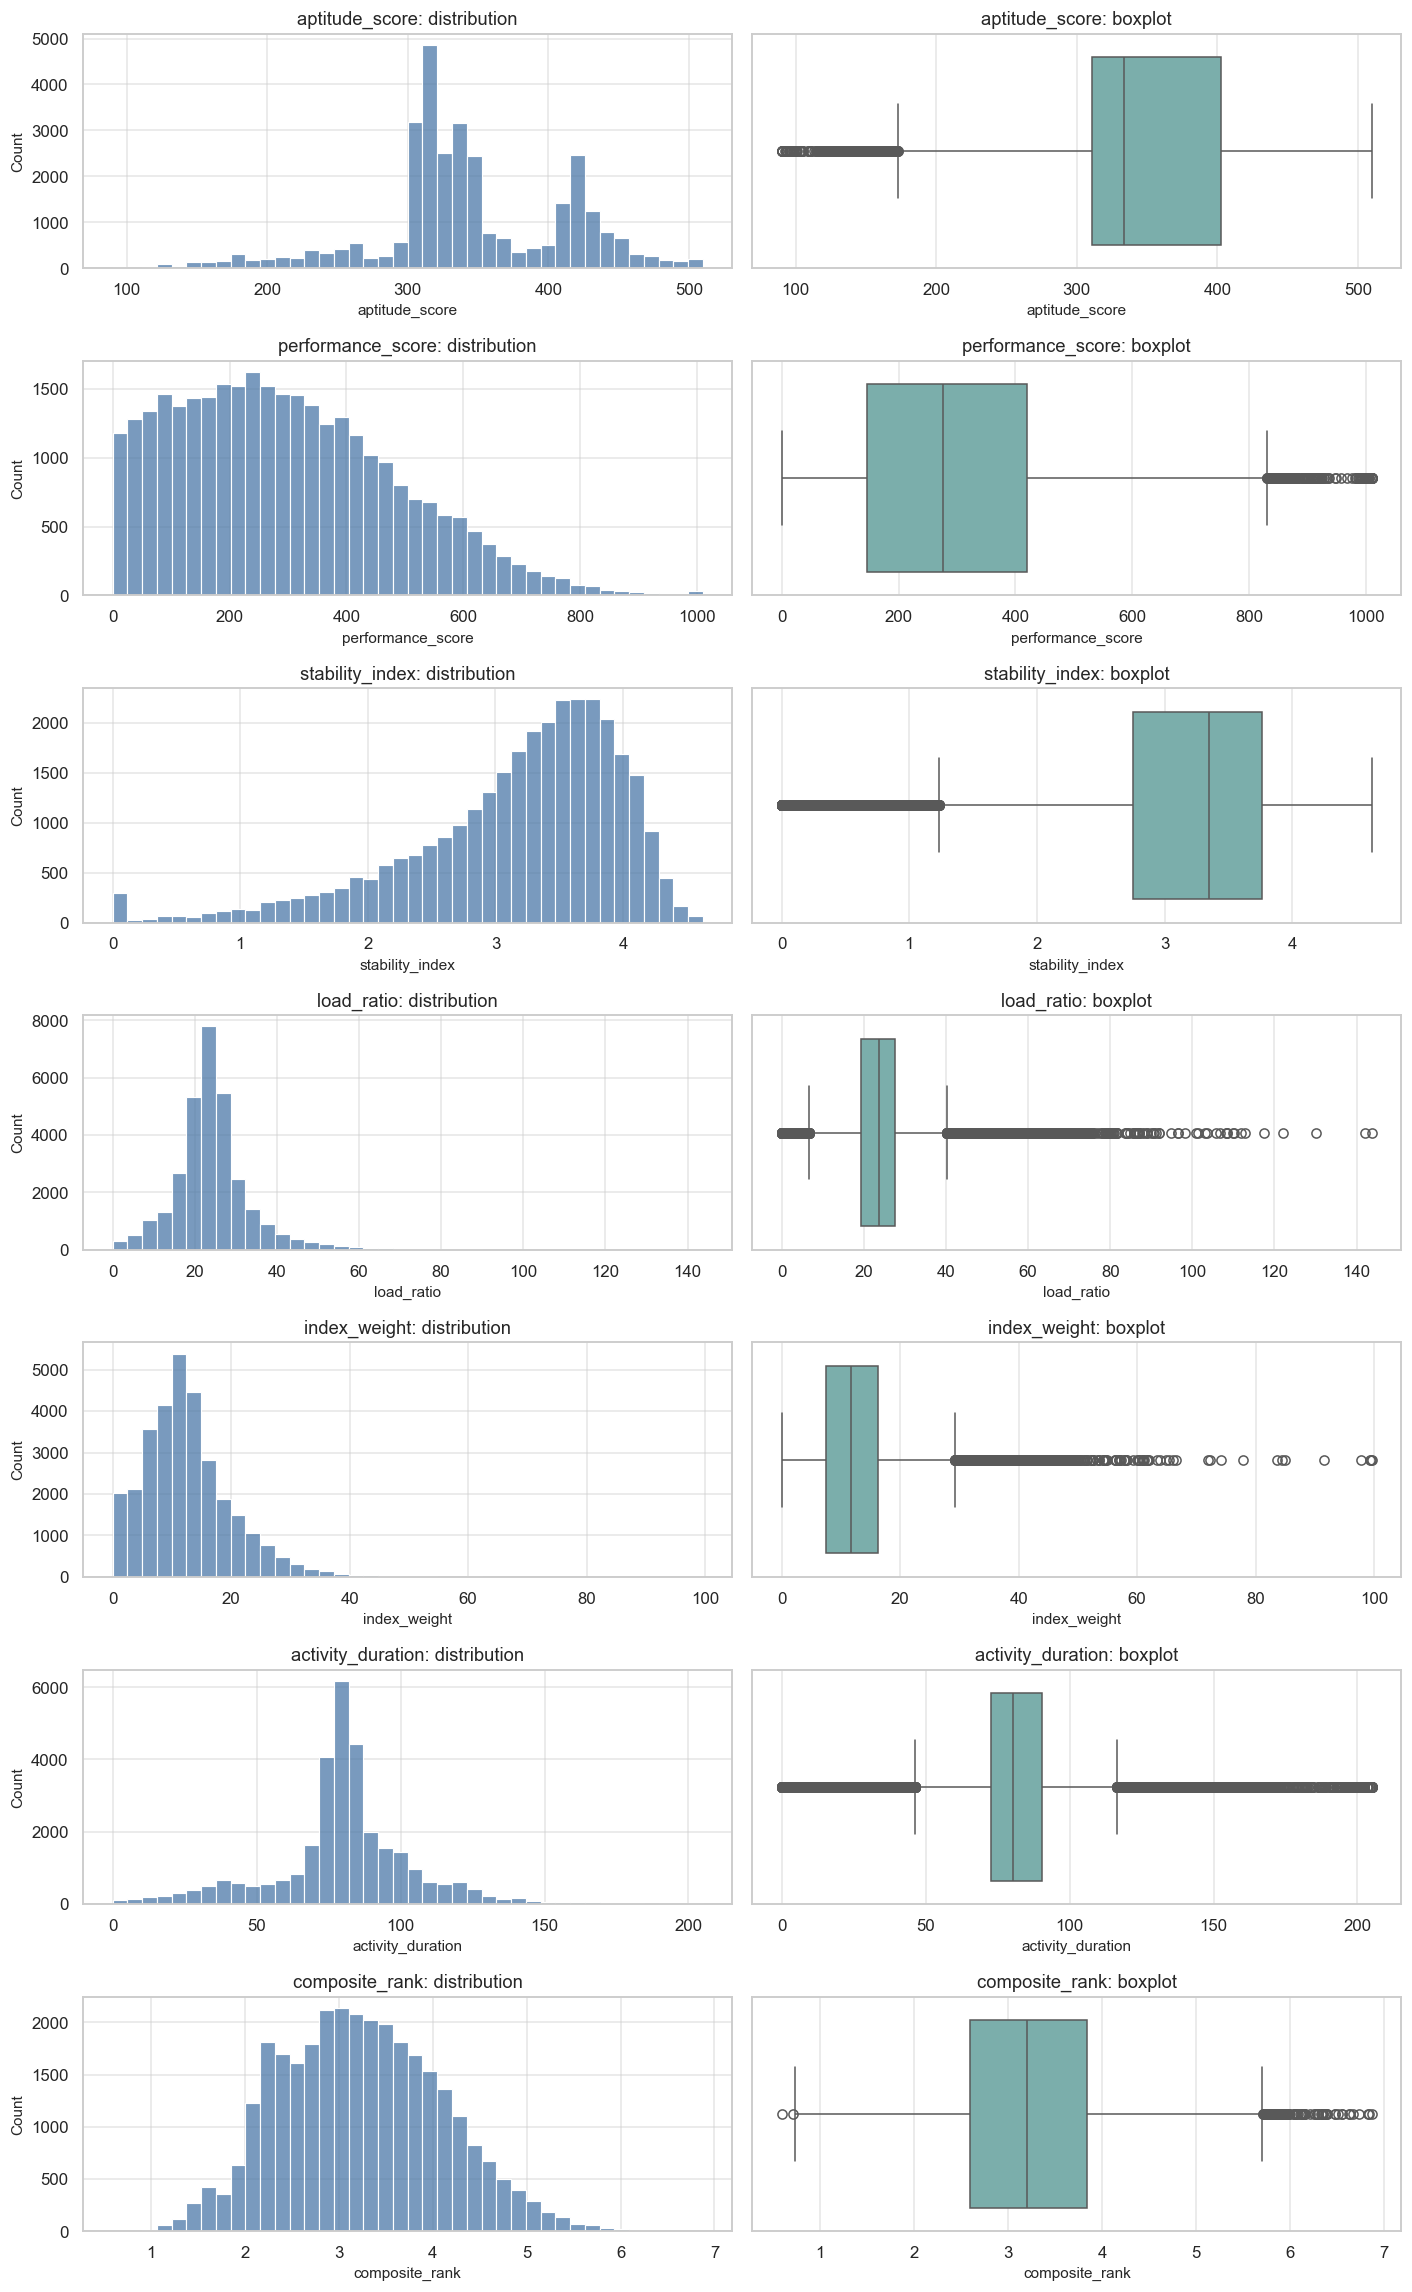

In [36]:
#Cell 12 — Code：数值分布与箱线图
#每个变量分别使用自己的横轴尺度。

fig, axes = plt.subplots(
    nrows=len(NUMERIC_COLS),
    ncols=2,
    figsize=(13, 3 * len(NUMERIC_COLS)),
)

for row, col in enumerate(NUMERIC_COLS):
    values = eda[col].dropna()

    if values.empty:
        for ax in axes[row]:
            ax.text(
                0.5, 0.5, "No observed values",
                ha="center", va="center",
                transform=ax.transAxes,
            )
            ax.set_title(col)
        continue

    sns.histplot(
        x=values,
        bins=40,
        color="#4C78A8",
        ax=axes[row, 0],
    )
    axes[row, 0].set_title(f"{col}: distribution")
    axes[row, 0].set_xlabel(col)

    sns.boxplot(
        x=values,
        color="#72B7B2",
        ax=axes[row, 1],
    )
    axes[row, 1].set_title(f"{col}: boxplot")

finish_figure(fig, "03_numeric_distributions")

In [37]:
#Cell 13 — Code：IQR 极端值诊断
#IQR 规则用于标记，不用于自动删除或截断。对 IQR = 0 的变量，保留统计但不应用该规则，避免产生误导。

outlier_rows = []

for col in NUMERIC_COLS:
    values = eda[col].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    rule_applicable = pd.notna(iqr) and iqr > 0

    if rule_applicable:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        flagged = values.lt(lower) | values.gt(upper)

        outlier_count = int(flagged.sum())
        outlier_pct = float(flagged.mean() * 100)
    else:
        lower = np.nan
        upper = np.nan
        outlier_count = np.nan
        outlier_pct = np.nan

    outlier_rows.append({
        "feature": col,
        "observed_count": len(values),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "iqr_rule_applied": rule_applicable,
        "flagged_count": outlier_count,
        "flagged_pct_of_observed": outlier_pct,
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
    .set_index("feature")
    .sort_values("flagged_pct_of_observed", ascending=False)
)

display(outlier_summary)

print(
    "IQR flags describe distribution tails; "
    "they do not establish that observations are erroneous."
)

save_table(outlier_summary, "iqr_outlier_summary.csv")

,observed_count,q1,q3,iqr,lower_bound,upper_bound,iqr_rule_applied,flagged_count,flagged_pct_of_observed
feature,,,,,,,,,
activity_duration,31107,72.7400,90.2600,17.5200,46.4600,116.5400,True,5347,17.1891
load_ratio,31107,19.2720,27.6570,8.3850,6.6945,40.2345,True,2526,8.1204
stability_index,31107,2.7510,3.7620,1.0110,1.2345,5.2785,True,1128,3.6262
index_weight,31106,7.5200,16.2300,8.7100,-5.5450,29.2950,True,1017,3.2695
aptitude_score,31105,310.5900,402.5600,91.9700,172.6350,540.5150,True,617,1.9836
performance_score,31107,146.5700,420.1750,273.6050,-263.8375,830.5825,True,154,0.4951
composite_rank,31108,2.5910,3.8380,1.2470,0.7205,5.7085,True,115,0.3697


IQR flags describe distribution tails; they do not establish that observations are erroneous.


In [38]:
#Cell 14 — Code：零值和特殊组合
#检查之前方案中特别提到的两种共同为零的情况。

zero_summary = pd.DataFrame({
    "observed_count": eda[NUMERIC_COLS].notna().sum(),
    "zero_count": eda[NUMERIC_COLS].eq(0).sum(),
})

zero_summary["zero_pct_of_observed"] = (
    zero_summary["zero_count"]
    / zero_summary["observed_count"].replace(0, np.nan)
    * 100
)

display(zero_summary)

zero_pairs = [
    ("performance_score", "stability_index"),
    ("load_ratio", "activity_duration"),
]

pair_rows = []

for first, second in zero_pairs:
    observed = eda[[first, second]].notna().all(axis=1)
    both_zero = observed & eda[first].eq(0) & eda[second].eq(0)

    pair_rows.append({
        "feature_1": first,
        "feature_2": second,
        "both_observed_count": int(observed.sum()),
        "both_zero_count": int(both_zero.sum()),
        "positive_rate_when_both_zero": (
            float(y.loc[both_zero].mean())
            if both_zero.any()
            else np.nan
        ),
    })

zero_pair_summary = pd.DataFrame(pair_rows)

display(zero_pair_summary)

save_table(zero_summary, "zero_value_summary.csv")
save_table(zero_pair_summary, "zero_pairs.csv", index=False)

,observed_count,zero_count,zero_pct_of_observed
aptitude_score,31105,0,0.0000
performance_score,31107,265,0.8519
stability_index,31107,265,0.8519
load_ratio,31107,38,0.1222
index_weight,31106,4,0.0129
activity_duration,31107,38,0.1222
composite_rank,31108,0,0.0000


,feature_1,feature_2,both_observed_count,both_zero_count,positive_rate_when_both_zero
0,performance_score,stability_index,31105,265,0.0000
1,load_ratio,activity_duration,31105,38,0.1579


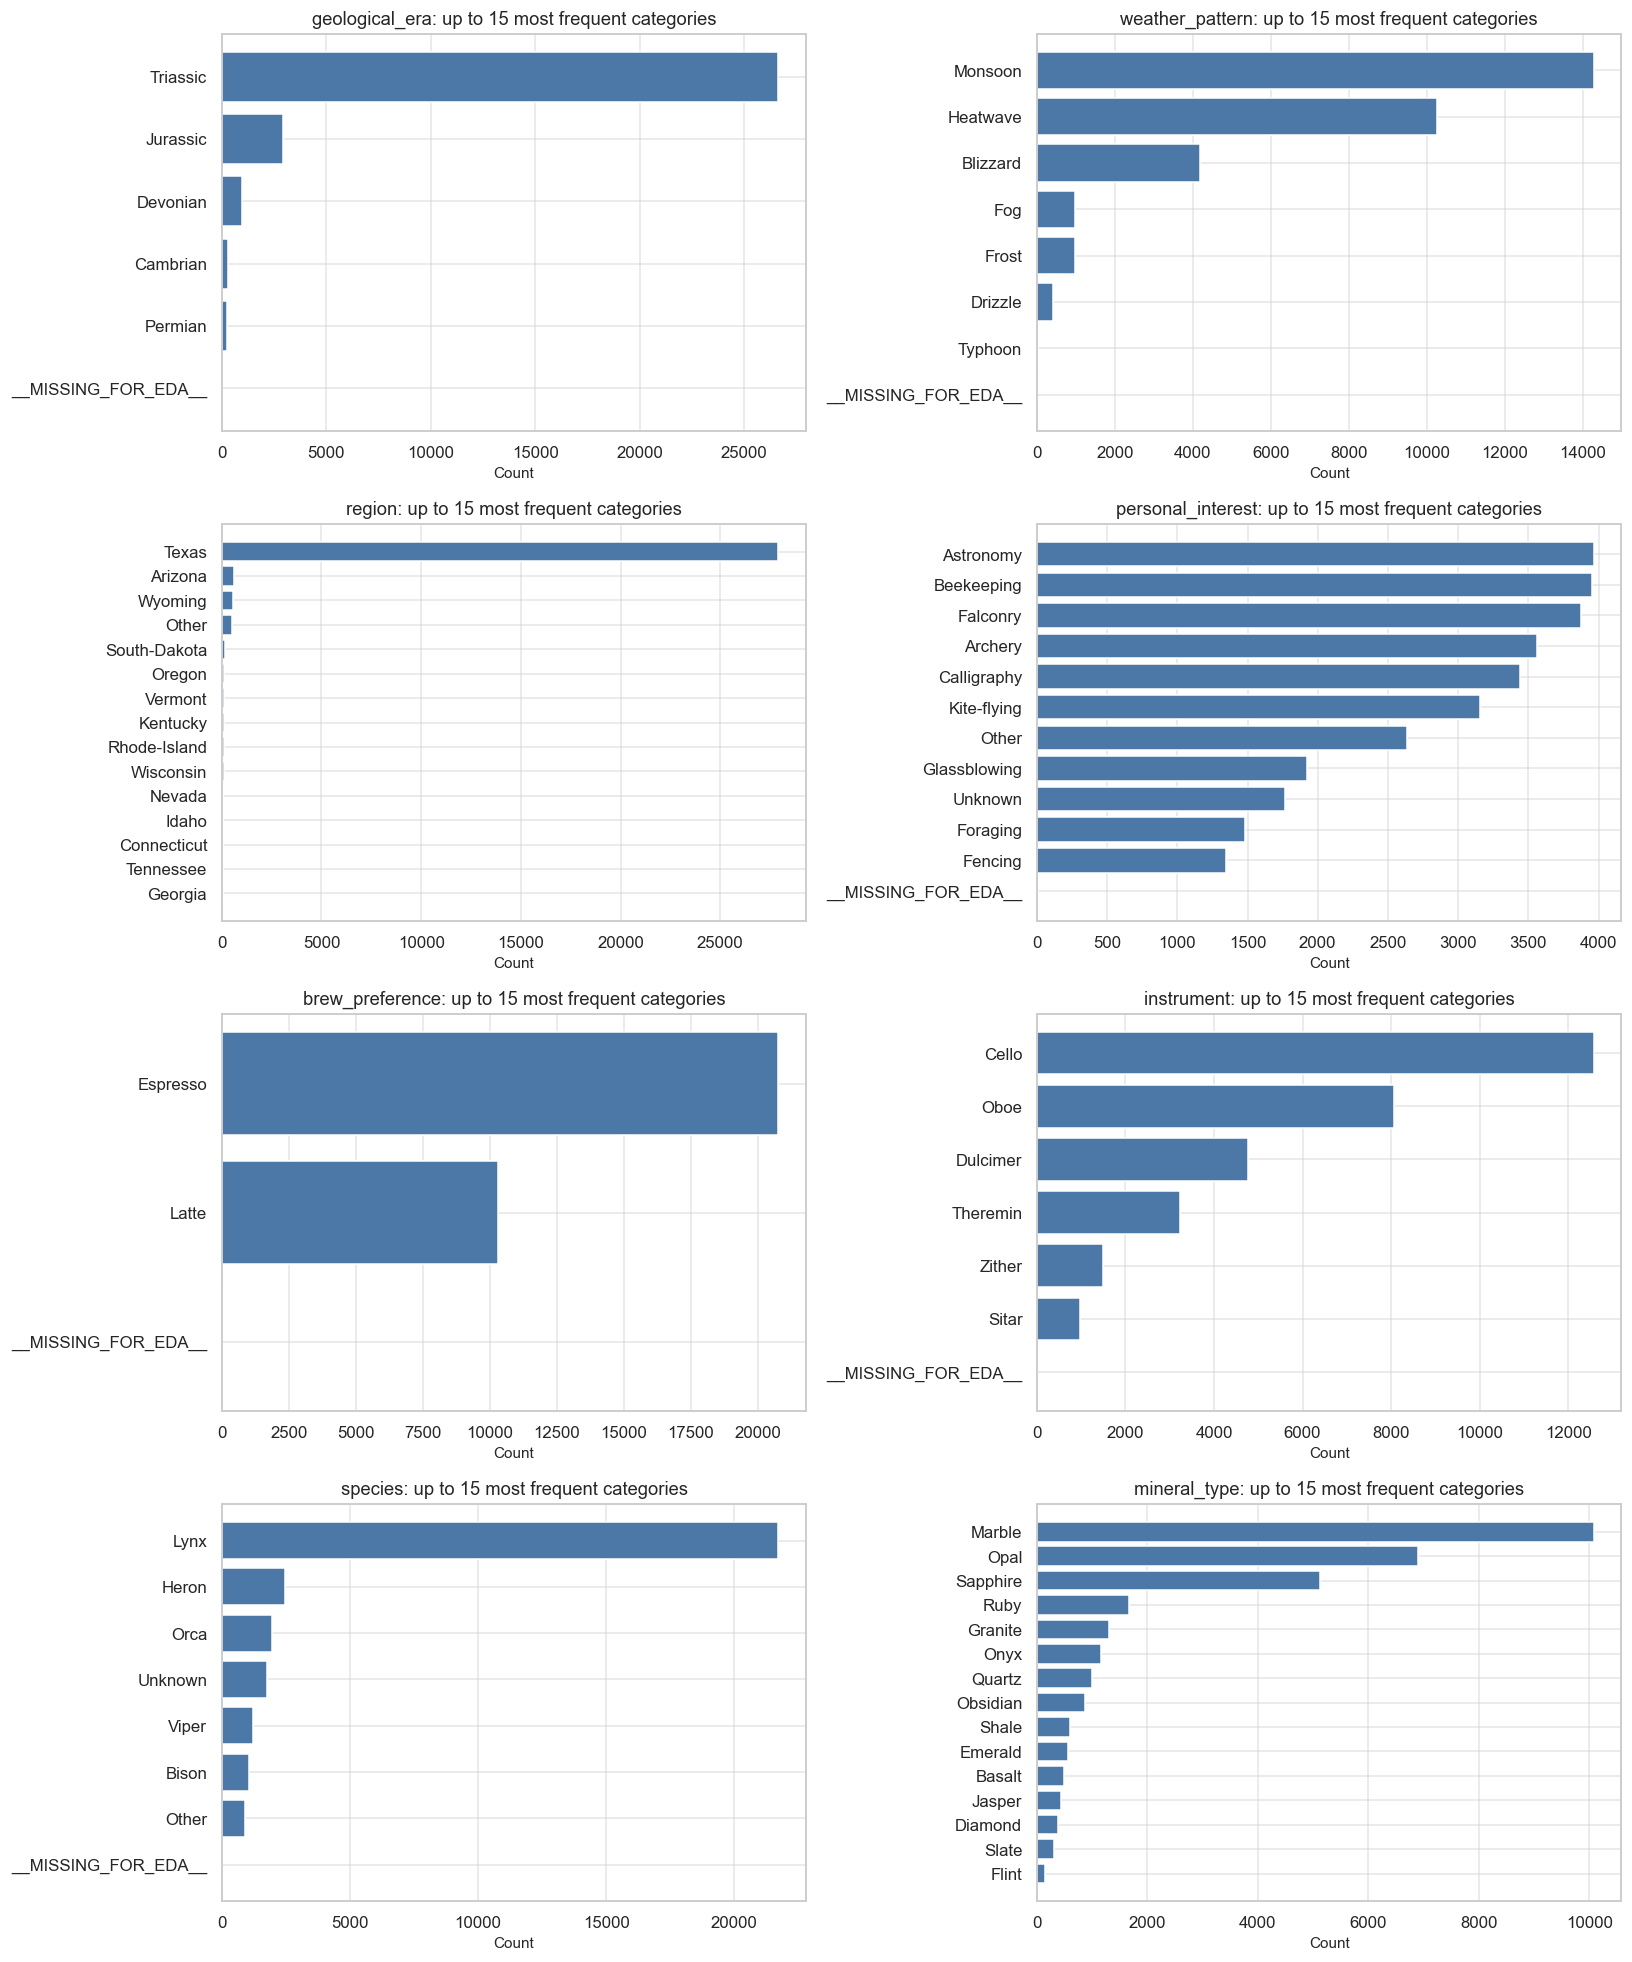

,feature,category,count,percentage
0,geological_era,Triassic,26641,85.6376
1,geological_era,Jurassic,2933,9.4281
2,geological_era,Devonian,983,3.1599
3,geological_era,Cambrian,298,0.9579
4,geological_era,Permian,252,0.8101
5,geological_era,__MISSING_FOR_EDA__,2,0.0064
6,weather_pattern,Monsoon,14273,45.8806
7,weather_pattern,Heatwave,10249,32.9454
8,weather_pattern,Blizzard,4191,13.4720
9,weather_pattern,Fog,987,3.1727


In [39]:
#Cell 15 — Code：类别特征分布
#缺失值使用专门的绘图标记，不与已有 Unknown 混合。

MISSING_DISPLAY = "__MISSING_FOR_EDA__"

for col in CATEGORICAL_COLS:
    if eda[col].eq(MISSING_DISPLAY).fillna(False).any():
        raise ValueError(
            f"{col} 中存在绘图缺失标记，请更换 MISSING_DISPLAY。"
        )


def category_values(series):
    return series.fillna(MISSING_DISPLAY)


category_tables = []

for col in CATEGORICAL_COLS:
    counts = category_values(eda[col]).value_counts()

    table = counts.rename_axis("category").reset_index(name="count")
    table.insert(0, "feature", col)
    table["percentage"] = table["count"] / len(eda) * 100

    category_tables.append(table)

category_distribution = pd.concat(category_tables, ignore_index=True)

ncols = 2
nrows = math.ceil(len(CATEGORICAL_COLS) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(15, 4.5 * nrows),
)
axes = np.asarray(axes).ravel()

for ax, col in zip(axes, CATEGORICAL_COLS):
    counts = category_values(eda[col]).value_counts().head(15)
    counts = counts.sort_values()

    ax.barh(
        counts.index.astype(str),
        counts.to_numpy(),
        color="#4C78A8",
    )

    ax.set_title(f"{col}: up to 15 most frequent categories")
    ax.set_xlabel("Count")

for ax in axes[len(CATEGORICAL_COLS):]:
    ax.set_visible(False)

finish_figure(fig, "04_categorical_distributions")

display(category_distribution)

save_table(
    category_distribution,
    "categorical_distributions.csv",
    index=False,
)

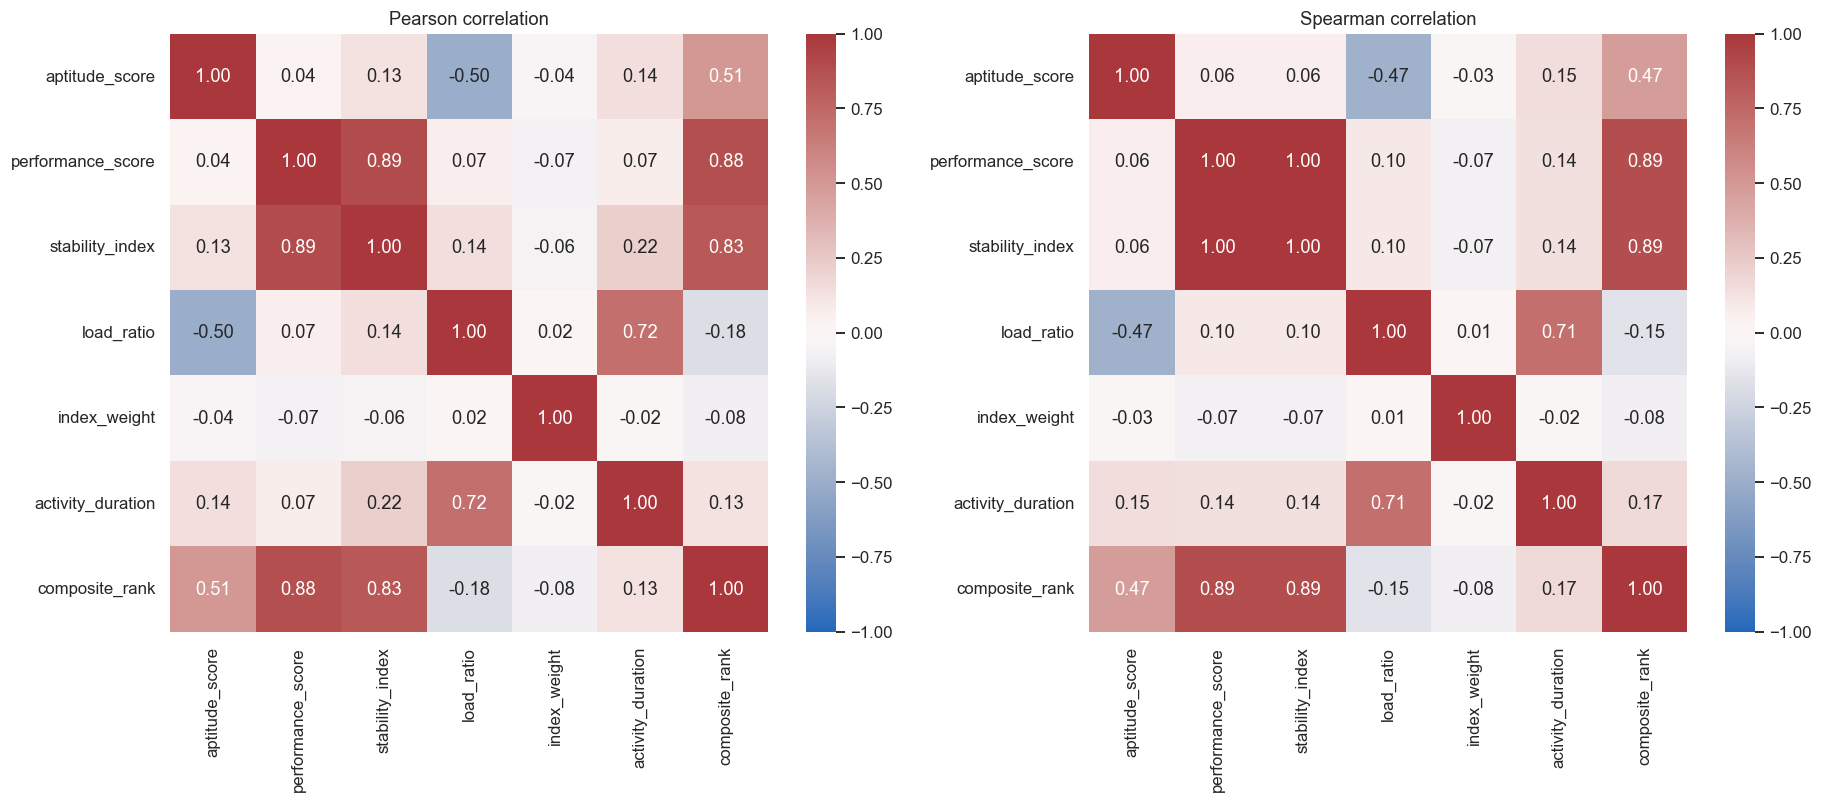

,feature_1,feature_2,pairwise_complete_n,pearson_r,spearman_r,abs_pearson_r
6,performance_score,stability_index,31105,0.8911,1.0000,0.8911
10,performance_score,composite_rank,31106,0.8799,0.8870,0.8799
14,stability_index,composite_rank,31106,0.8299,0.8870,0.8299
16,load_ratio,activity_duration,31105,0.7172,0.7114,0.7172
5,aptitude_score,composite_rank,31104,0.5064,0.4701,0.5064
2,aptitude_score,load_ratio,31103,-0.5040,-0.4745,0.5040
13,stability_index,activity_duration,31105,0.2228,0.1374,0.2228
17,load_ratio,composite_rank,31106,-0.1802,-0.1522,0.1802
11,stability_index,load_ratio,31105,0.1450,0.0980,0.1450
4,aptitude_score,activity_duration,31103,0.1431,0.1514,0.1431


Pairs with |Pearson r| >= 0.80:


,feature_1,feature_2,pairwise_complete_n,pearson_r,spearman_r,abs_pearson_r
6,performance_score,stability_index,31105,0.8911,1.0000,0.8911
10,performance_score,composite_rank,31106,0.8799,0.8870,0.8799
14,stability_index,composite_rank,31106,0.8299,0.8870,0.8299


In [40]:
#Cell 16 — Code：Unknown、Other、稀有类别与主导类别
#这里将占比低于 1% 的非空类别标为“稀有”，只是诊断阈值，不直接触发合并。

pearson_corr = eda[NUMERIC_COLS].corr(method="pearson")
spearman_corr = eda[NUMERIC_COLS].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, matrix, title in [
    (axes[0], pearson_corr, "Pearson correlation"),
    (axes[1], spearman_corr, "Spearman correlation"),
]:
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        ax=ax,
    )
    ax.set_title(title)

finish_figure(fig, "05_numeric_correlations")

pair_rows = []

for i, first in enumerate(NUMERIC_COLS):
    for second in NUMERIC_COLS[i + 1:]:
        pair_rows.append({
            "feature_1": first,
            "feature_2": second,
            "pairwise_complete_n": int(
                eda[[first, second]].notna().all(axis=1).sum()
            ),
            "pearson_r": pearson_corr.loc[first, second],
            "spearman_r": spearman_corr.loc[first, second],
        })

correlation_pairs = pd.DataFrame(pair_rows)
correlation_pairs["abs_pearson_r"] = correlation_pairs["pearson_r"].abs()

correlation_pairs = correlation_pairs.sort_values(
    "abs_pearson_r",
    ascending=False,
)

display(correlation_pairs)

print("Pairs with |Pearson r| >= 0.80:")
display(
    correlation_pairs.loc[
        correlation_pairs["abs_pearson_r"] >= 0.80
    ]
)

save_table(pearson_corr, "pearson_correlation.csv")
save_table(spearman_corr, "spearman_correlation.csv")
save_table(correlation_pairs, "correlation_pairs.csv", index=False)

aptitude_score                           performance_score           \
               count     mean   median     std             count     mean   
label                                                                       
no             23643 329.3789 324.5200 65.4556             23643 272.6576   
yes             7462 382.5388 401.3150 63.8826              7464 372.0138   

                        stability_index                      load_ratio  \
        median      std           count   mean median    std      count   
label                                                                     
no    237.3900 193.3555           23645 3.0275 3.2080 0.9090      23643   
yes   360.7750 144.1933            7462 3.5651 3.6130 0.4116       7464   

                              index_weight                         \
         mean  median     std        count    mean  median    std   
label                                                               
no    24.4393 23.7650 10.4405        23644 12.7556 11.7800 7.8134   
yes   24.3729 23.4635  8.0523         7462 12.6138 11.5900 7.5330   

      activity_duration                         composite_rank                \
                  count    mean  median     std          count   mean median   
label                                                                          
no                23643 77.1109 79.0300 25.3870          23644 3.0669 2.9890   
yes                7464 90.6623 86.1000 23.0646           7464 3.7834 3.7550   

              
         std  
label         
no    0.8510  
yes   0.6849

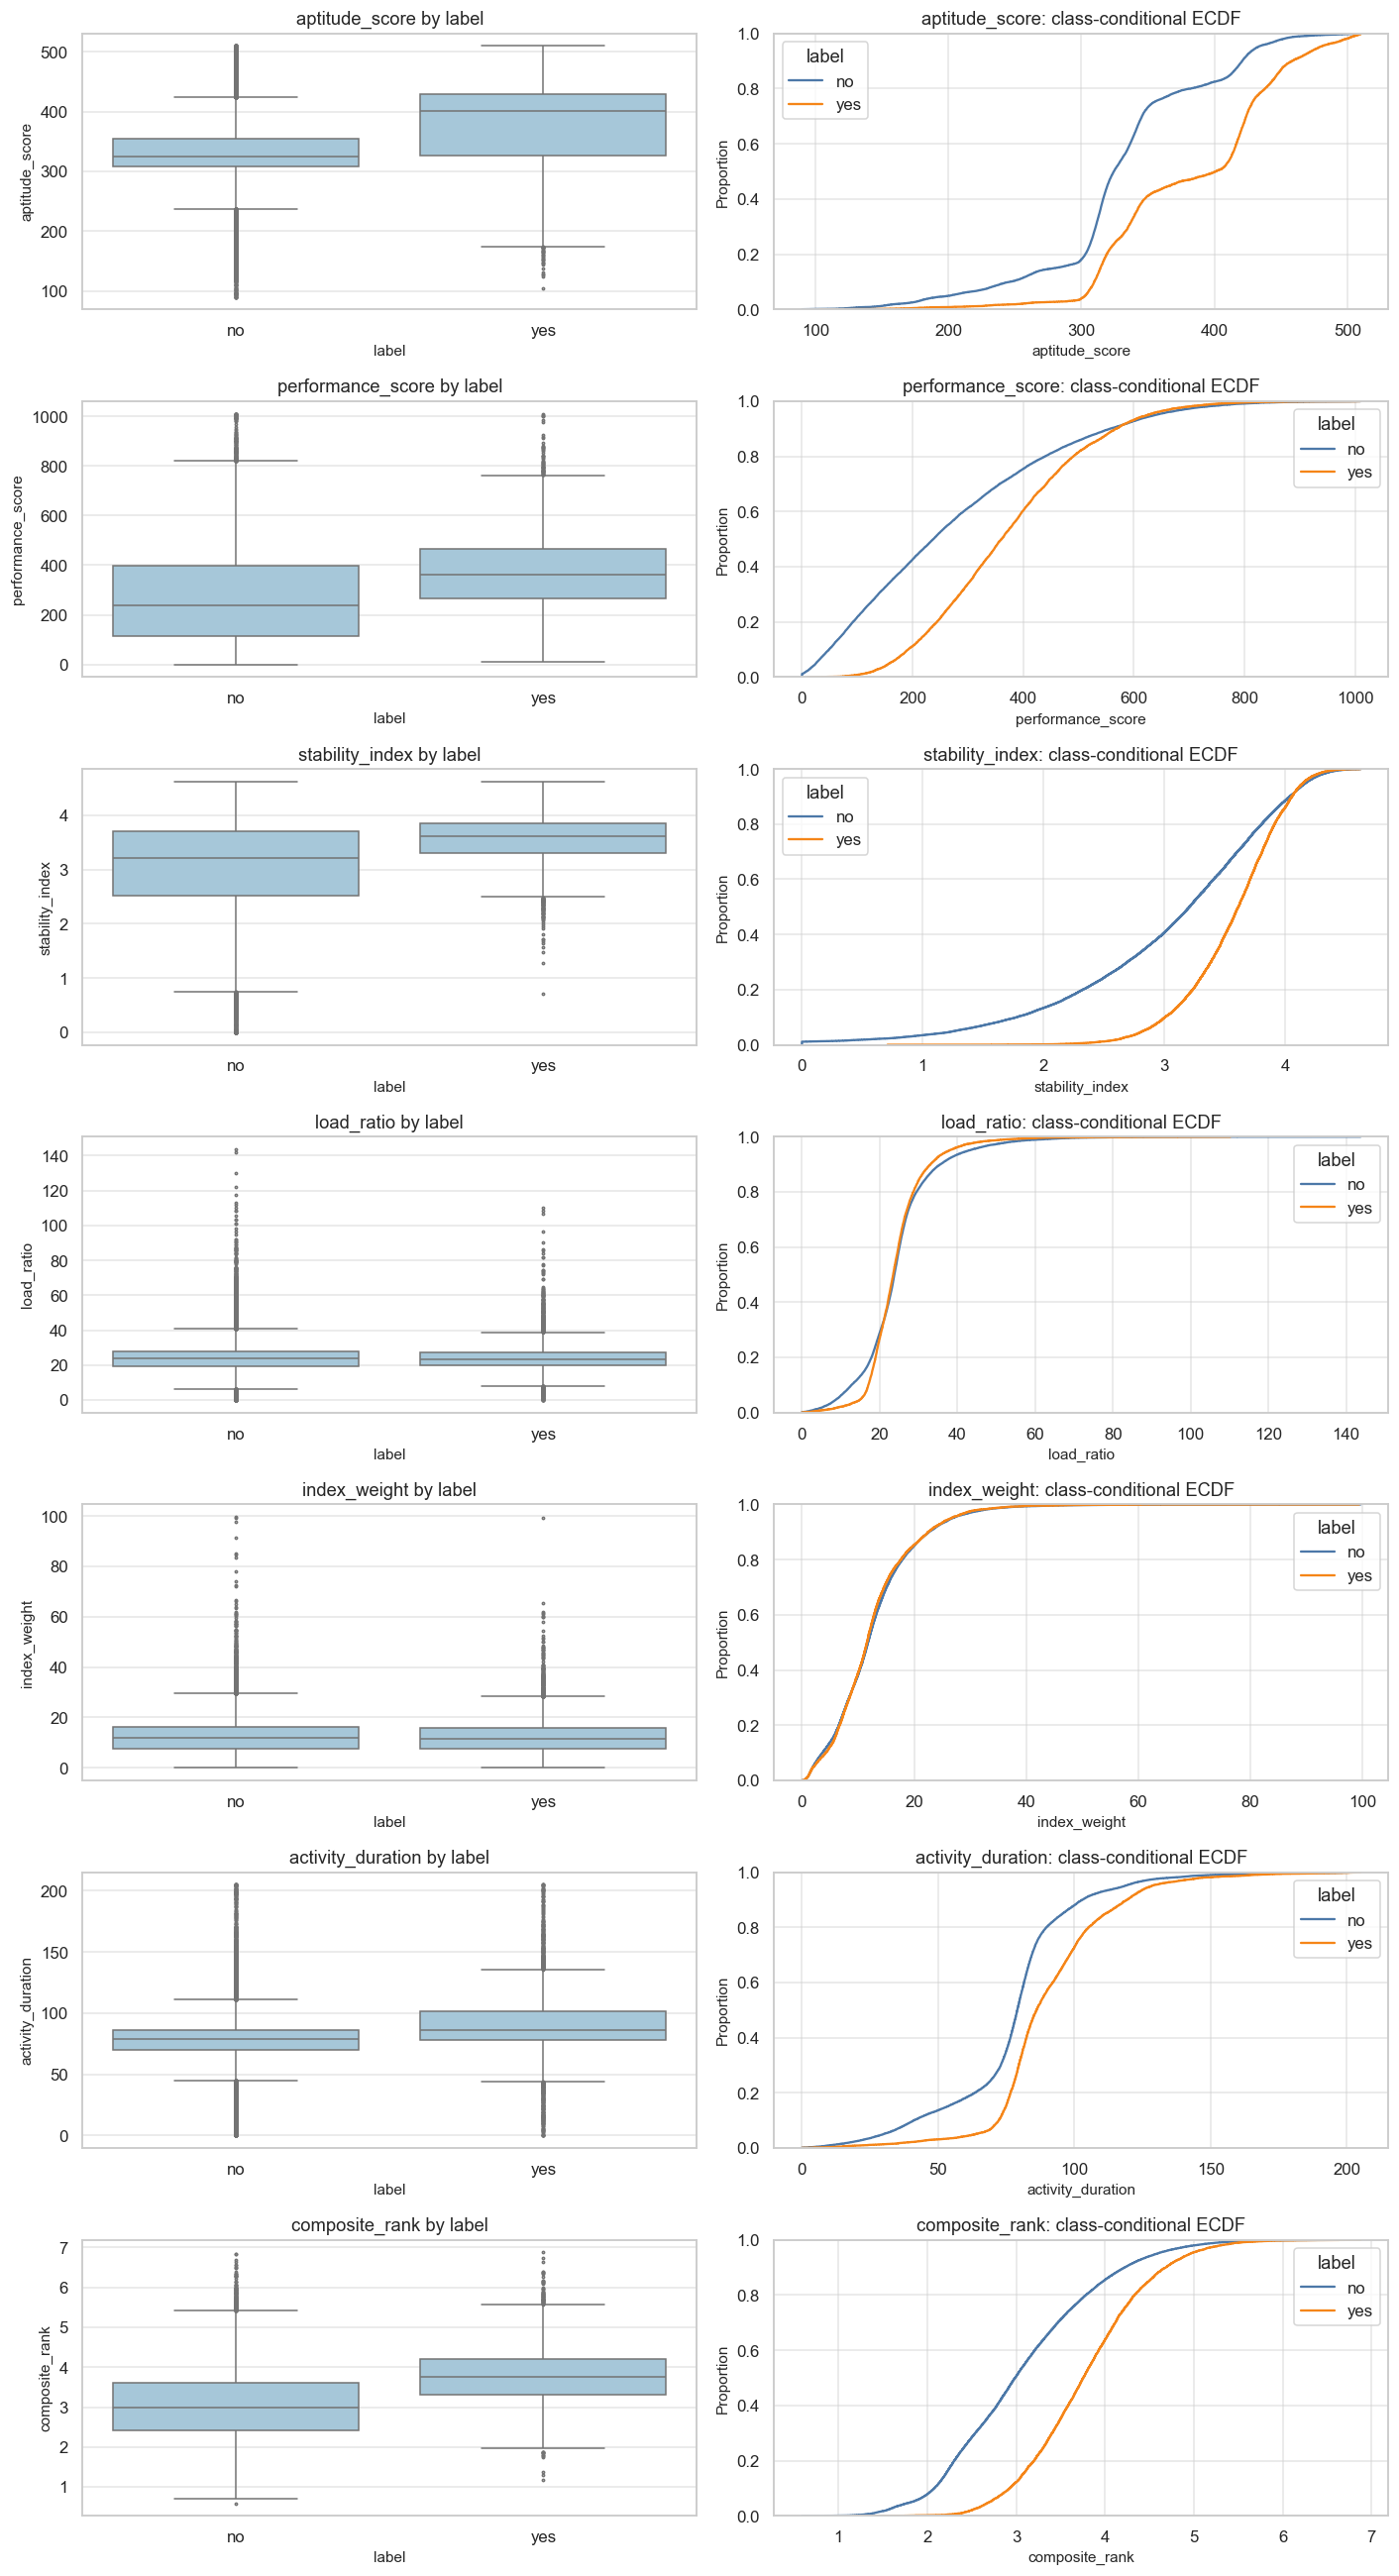

In [41]:
#Cell 17 — Code：数值特征相关性
'''同时检查：
- Pearson：线性相关。
- Spearman：基于排序的单调相关。
计算使用每对变量共同非空的记录，不先插补。

相关性高不意味着一定删除特征，也不能单凭相关性认定数据泄漏。

'''

numeric_by_label = (
    eda.groupby(TARGET)[NUMERIC_COLS]
    .agg(["count", "mean", "median", "std"])
    .reindex(LABEL_ORDER)
)

display(numeric_by_label)

fig, axes = plt.subplots(
    len(NUMERIC_COLS),
    2,
    figsize=(13, 3.4 * len(NUMERIC_COLS)),
)

for row, col in enumerate(NUMERIC_COLS):
    sns.boxplot(
        data=eda,
        x=TARGET,
        y=col,
        order=LABEL_ORDER,
        color="#9ECAE1",
        showfliers=True,
        fliersize=1.5,
        ax=axes[row, 0],
    )
    axes[row, 0].set_title(f"{col} by label")

    for label in LABEL_ORDER:
        values = eda.loc[eda[TARGET].eq(label), col].dropna()

        if not values.empty:
            sns.ecdfplot(
                x=values,
                label=label,
                color=PALETTE[label],
                ax=axes[row, 1],
            )

    axes[row, 1].set_title(f"{col}: class-conditional ECDF")
    axes[row, 1].set_xlabel(col)
    axes[row, 1].legend(title=TARGET)

finish_figure(fig, "06_numeric_features_by_label")
save_table(numeric_by_label, "numeric_summary_by_label.csv")

aptitude_score                           performance_score           \
               count     mean   median     std             count     mean   
label                                                                       
no             23643 329.3789 324.5200 65.4556             23643 272.6576   
yes             7462 382.5388 401.3150 63.8826              7464 372.0138   

                        stability_index                      load_ratio  \
        median      std           count   mean median    std      count   
label                                                                     
no    237.3900 193.3555           23645 3.0275 3.2080 0.9090      23643   
yes   360.7750 144.1933            7462 3.5651 3.6130 0.4116       7464   

                              index_weight                         \
         mean  median     std        count    mean  median    std   
label                                                               
no    24.4393 23.7650 10.4405        23644 12.7556 11.7800 7.8134   
yes   24.3729 23.4635  8.0523         7462 12.6138 11.5900 7.5330   

      activity_duration                         composite_rank                \
                  count    mean  median     std          count   mean median   
label                                                                          
no                23643 77.1109 79.0300 25.3870          23644 3.0669 2.9890   
yes                7464 90.6623 86.1000 23.0646           7464 3.7834 3.7550   

              
         std  
label         
no    0.8510  
yes   0.6849

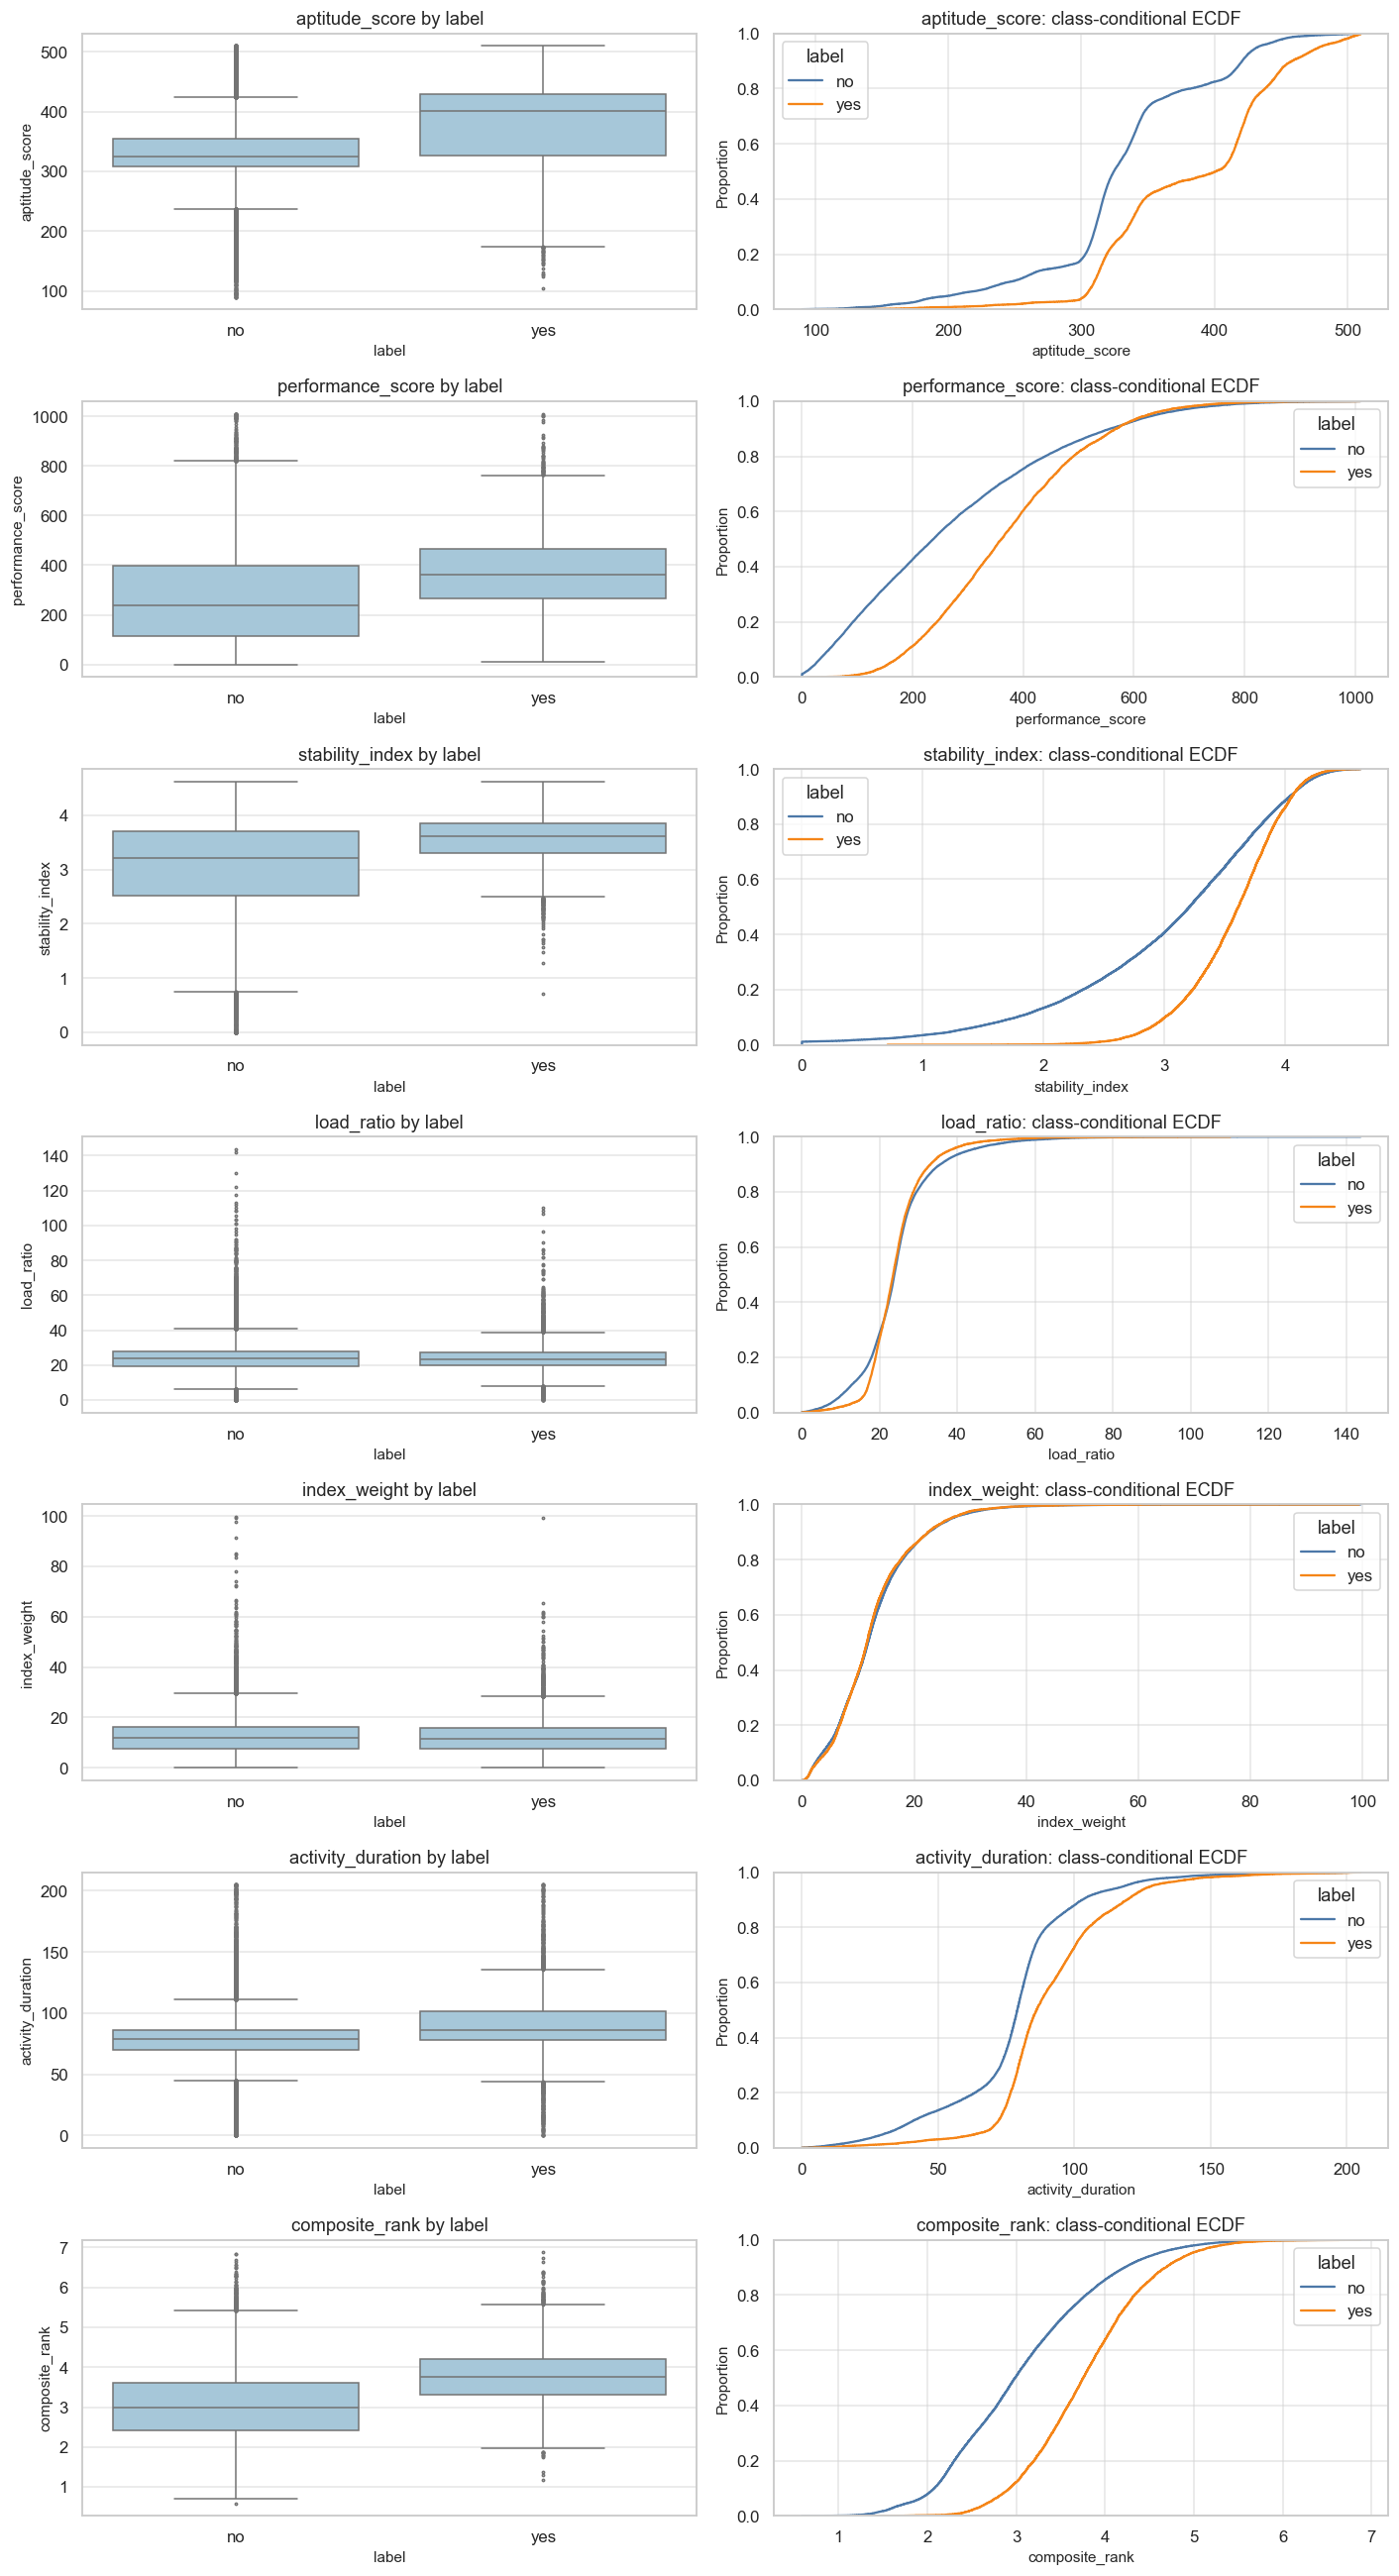

In [42]:
#Cell 18 — Code：数值特征与标签的关系
#箱线图查看两类分布差异；ECDF 展示各类内部的累计比例，更便于比较不平衡类别。

#ECDF 曲线接近，表示该变量的单变量分布区分度可能有限；不能因此断定它在多变量模型中没有价值。

numeric_by_label = (
    eda.groupby(TARGET)[NUMERIC_COLS]
    .agg(["count", "mean", "median", "std"])
    .reindex(LABEL_ORDER)
)

display(numeric_by_label)

fig, axes = plt.subplots(
    len(NUMERIC_COLS),
    2,
    figsize=(13, 3.4 * len(NUMERIC_COLS)),
)

for row, col in enumerate(NUMERIC_COLS):
    sns.boxplot(
        data=eda,
        x=TARGET,
        y=col,
        order=LABEL_ORDER,
        color="#9ECAE1",
        showfliers=True,
        fliersize=1.5,
        ax=axes[row, 0],
    )
    axes[row, 0].set_title(f"{col} by label")

    for label in LABEL_ORDER:
        values = eda.loc[eda[TARGET].eq(label), col].dropna()

        if not values.empty:
            sns.ecdfplot(
                x=values,
                label=label,
                color=PALETTE[label],
                ax=axes[row, 1],
            )

    axes[row, 1].set_title(f"{col}: class-conditional ECDF")
    axes[row, 1].set_xlabel(col)
    axes[row, 1].legend(title=TARGET)

finish_figure(fig, "06_numeric_features_by_label")
save_table(numeric_by_label, "numeric_summary_by_label.csv")

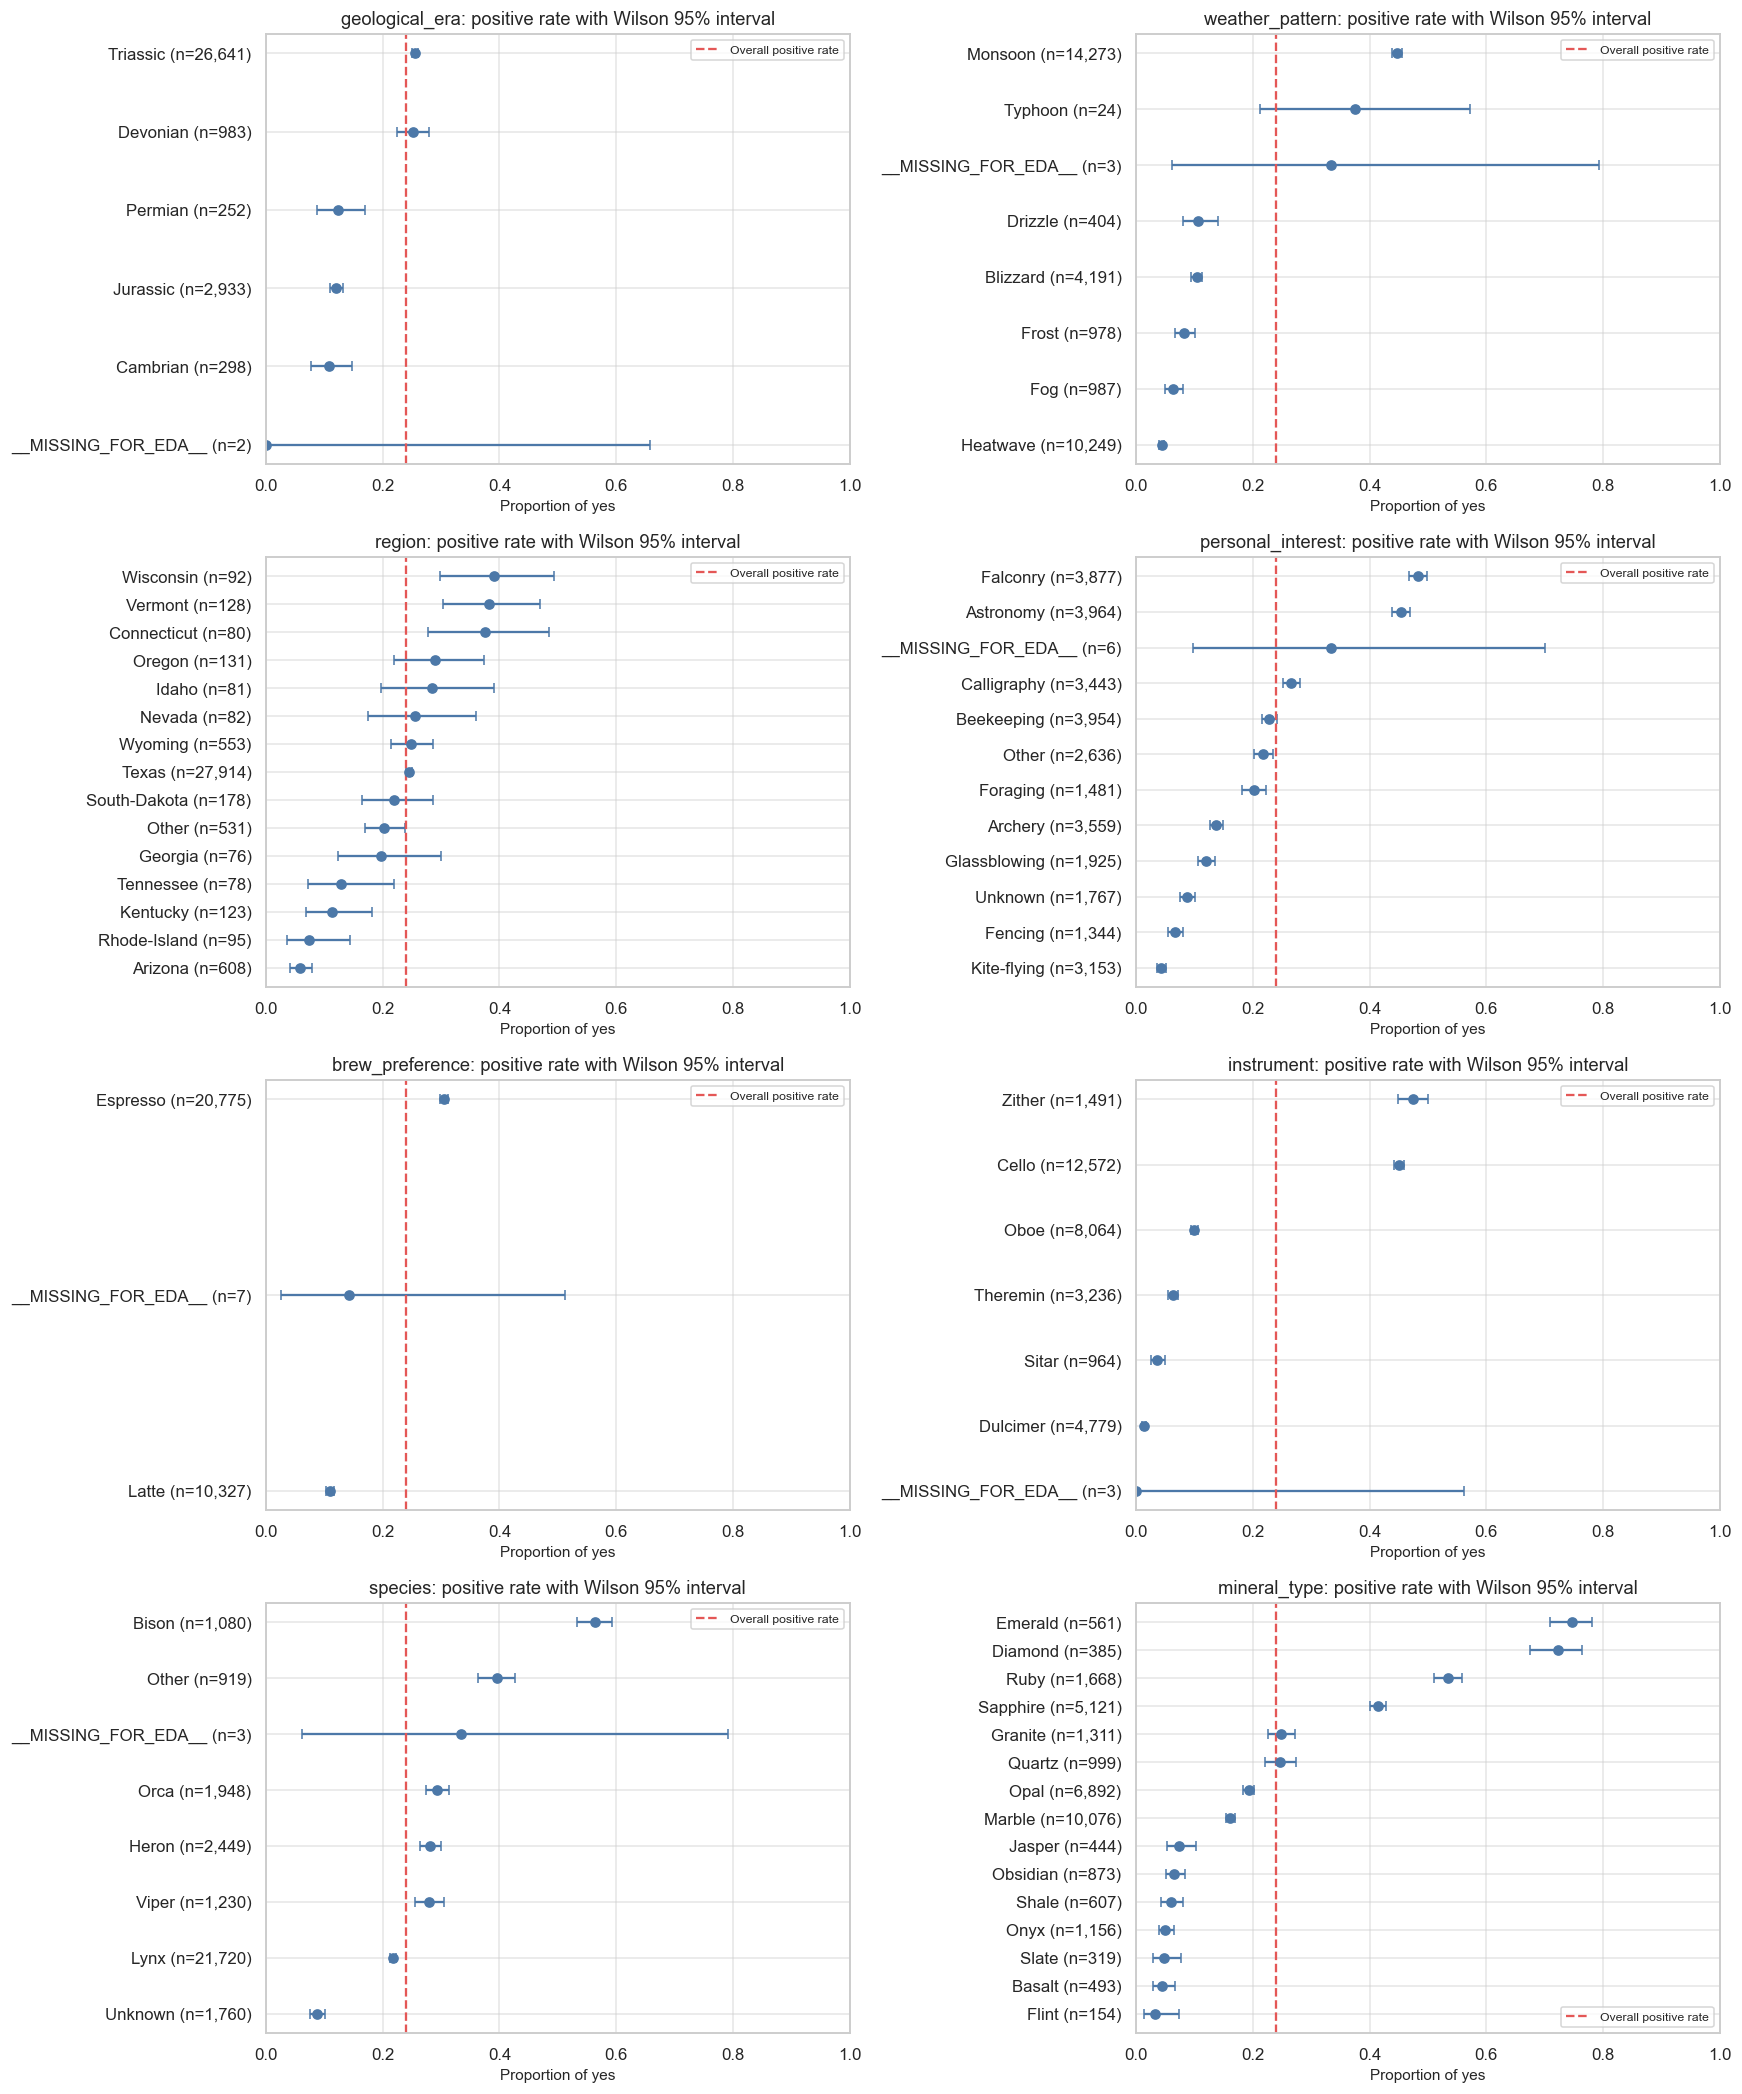

,feature,category,n,yes_count,positive_rate,ci_low,ci_high
0,geological_era,Triassic,26641,6801,0.2553,0.2501,0.2606
1,geological_era,Jurassic,2933,353,0.1204,0.1091,0.1326
2,geological_era,Devonian,983,247,0.2513,0.2252,0.2793
3,geological_era,Cambrian,298,32,0.1074,0.0771,0.1477
4,geological_era,Permian,252,31,0.1230,0.0880,0.1693
5,geological_era,__MISSING_FOR_EDA__,2,0,0.0000,0.0000,0.6576
6,weather_pattern,Monsoon,14273,6385,0.4473,0.4392,0.4555
7,weather_pattern,Heatwave,10249,449,0.0438,0.0400,0.0479
8,weather_pattern,Blizzard,4191,434,0.1036,0.0947,0.1131
9,weather_pattern,Fog,987,63,0.0638,0.0502,0.0808


In [43]:
#Cell 19 — Code：类别特征与标签的关系
'''每个类别展示 yes 比例和样本量。误差线使用 Wilson 95% 区间，提醒你小样本类别的不确定性。
这些区间基于二项抽样近似，未做多重比较校正，仅用于探索。

不要将某个只有十几条记录、但 yes 比例很高的类别直接解释成“最重要特征”。'''

def wilson_interval(successes, totals, z=1.959963984540054):
    successes = np.asarray(successes, dtype=float)
    totals = np.asarray(totals, dtype=float)

    p = successes / totals
    denominator = 1 + z**2 / totals

    center = (p + z**2 / (2 * totals)) / denominator

    half_width = (
        z
        * np.sqrt(
            p * (1 - p) / totals
            + z**2 / (4 * totals**2)
        )
        / denominator
    )

    return center - half_width, center + half_width


category_target_tables = []

fig, axes = plt.subplots(
    math.ceil(len(CATEGORICAL_COLS) / 2),
    2,
    figsize=(16, 4.8 * math.ceil(len(CATEGORICAL_COLS) / 2)),
)
axes = np.asarray(axes).ravel()

for ax, col in zip(axes, CATEGORICAL_COLS):
    temporary = pd.DataFrame({
        "category": category_values(eda[col]),
        "positive": y,
    })

    stats = (
        temporary.groupby("category")["positive"]
        .agg(n="size", yes_count="sum")
        .sort_values("n", ascending=False)
    )

    stats["positive_rate"] = stats["yes_count"] / stats["n"]

    low, high = wilson_interval(stats["yes_count"], stats["n"])
    stats["ci_low"] = low
    stats["ci_high"] = high

    export = stats.reset_index()
    export.insert(0, "feature", col)
    category_target_tables.append(export)

    # 全部类别保存到表；图中最多显示样本最多的 15 类。
    plot_stats = stats.head(15).sort_values("positive_rate")

    positions = np.arange(len(plot_stats))
    rates = plot_stats["positive_rate"].to_numpy()

    errors = np.vstack([
        rates - plot_stats["ci_low"].to_numpy(),
        plot_stats["ci_high"].to_numpy() - rates,
    ])
    errors = np.maximum(errors, 0)

    ax.errorbar(
        rates,
        positions,
        xerr=errors,
        fmt="o",
        color="#4C78A8",
        capsize=3,
    )

    ax.set_yticks(positions)
    ax.set_yticklabels([
        f"{category} (n={int(row['n']):,})"
        for category, row in plot_stats.iterrows()
    ])

    ax.axvline(
        positive_rate,
        linestyle="--",
        color="#E45756",
        label="Overall positive rate",
    )

    ax.set_xlim(0, 1)
    ax.set_xlabel("Proportion of yes")
    ax.set_title(f"{col}: positive rate with Wilson 95% interval")
    ax.legend(fontsize=8)

for ax in axes[len(CATEGORICAL_COLS):]:
    ax.set_visible(False)

finish_figure(fig, "07_categorical_positive_rates")

category_target_summary = pd.concat(
    category_target_tables,
    ignore_index=True,
)

display(category_target_summary)

save_table(
    category_target_summary,
    "categorical_target_summary.csv",
    index=False,
)

In [44]:
#Cell 20 — Code：缺失情况是否与标签有关
#这里仅检查描述性关系，不因为少数缺失记录的正类率高，就直接增加缺失指示变量。

missing_target_rows = []

for col in FEATURE_COLS:
    missing = eda[col].isna()

    if not missing.any():
        continue

    for status, mask in [
        ("observed", ~missing),
        ("missing", missing),
    ]:
        count = int(mask.sum())

        missing_target_rows.append({
            "feature": col,
            "status": status,
            "n": count,
            "yes_count": int(y.loc[mask].sum()),
            "positive_rate": (
                float(y.loc[mask].mean()) if count else np.nan
            ),
        })

missing_target_summary = pd.DataFrame(
    missing_target_rows,
    columns=["feature", "status", "n", "yes_count", "positive_rate"],
)

display(missing_target_summary)

save_table(
    missing_target_summary,
    "missingness_by_label.csv",
    index=False,
)

,feature,status,n,yes_count,positive_rate
0,aptitude_score,observed,31105,7462,0.2399
1,aptitude_score,missing,4,2,0.5000
2,performance_score,observed,31107,7464,0.2399
3,performance_score,missing,2,0,0.0000
4,stability_index,observed,31107,7462,0.2399
5,stability_index,missing,2,2,1.0000
6,load_ratio,observed,31107,7464,0.2399
7,load_ratio,missing,2,0,0.0000
8,index_weight,observed,31106,7462,0.2399
9,index_weight,missing,3,2,0.6667


In [45]:
#Cell 21 — Code：导出机器可读摘要与报告用描述
#统计摘要保存到 outputs/eda/eda_summary.json

summary = {
    "source": {
        "filename": TRAIN_PATH.name,
        "sha256": hashlib.sha256(TRAIN_PATH.read_bytes()).hexdigest(),
    },
    "scope": {
        "test_data_used": False,
        "quality_checks_population": "all training rows",
        "distribution_analysis_population": "labeled training rows",
    },
    "shape": {
        "raw_training_rows": int(len(df)),
        "labeled_training_rows": int(len(eda)),
        "features": len(FEATURE_COLS),
        "numerical_features": len(NUMERIC_COLS),
        "categorical_features": len(CATEGORICAL_COLS),
    },
    "missingness": {
        "missing_target_rows": int(missing_target_mask.sum()),
        "missing_feature_cells_all_rows": int(
            df[FEATURE_COLS].isna().sum().sum()
        ),
        "rows_with_missing_features_all_rows": int(
            df[FEATURE_COLS].isna().any(axis=1).sum()
        ),
        "per_column_all_rows": {
            col: int(df[col].isna().sum())
            for col in EXPECTED_COLS
        },
    },
    "duplicates_after_whitespace_normalization": {
        "full_duplicates_beyond_first": full_duplicates,
        "feature_duplicates_beyond_first": feature_duplicates,
        "conflicting_feature_groups": int(len(conflicting_groups)),
    },
    "target": {
        "counts": {
            label: int(class_counts[label])
            for label in LABEL_ORDER
        },
        "positive_rate": positive_rate,
        "majority_class_accuracy_reference": majority_accuracy,
        "constant_score_ap_reference": positive_rate,
    },
    "environment": {
        "python": platform.python_version(),
        **{
            package: version(package)
            for package in ["numpy", "pandas", "matplotlib", "seaborn"]
        },
    },
}

summary_path = EDA_DIR / "eda_summary.json"

summary_path.write_text(
    json.dumps(summary, indent=2, ensure_ascii=False, allow_nan=False),
    encoding="utf-8",
)

report_description = (
    f"The supplied training set contained {len(df):,} observations "
    f"and {len(FEATURE_COLS)} predictors "
    f"({len(NUMERIC_COLS)} numerical and "
    f"{len(CATEGORICAL_COLS)} categorical). "
    f"After excluding {missing_target_mask.sum():,} observations "
    f"with missing targets, {len(eda):,} labeled observations "
    f"remained for supervised analysis. "
    f"The positive class accounted for {positive_rate:.2%} "
    f"of these observations. "
    f"Across all supplied training rows, "
    f"{df[FEATURE_COLS].isna().sum().sum():,} feature values "
    f"were missing."
)

print(report_description)
print("\nSummary saved to:", summary_path)

The supplied training set contained 31,112 observations and 15 predictors (7 numerical and 8 categorical). After excluding 3 observations with missing targets, 31,109 labeled observations remained for supervised analysis. The positive class accounted for 23.99% of these observations. Across all supplied training rows, 47 feature values were missing.

Summary saved to: F:\NTU Python\IN6227\IN6227-Assignment-1\outputs\eda\eda_summary.json


## EDA findings

### Dataset and target

- The original training set contains [N] rows and 15 predictors.
- [N] rows have missing targets and are excluded from supervised analysis.
- The positive class represents [X%] of labeled training observations.
- The majority-class accuracy reference is [X%], so accuracy alone
  is insufficient for comparing classifiers.

### Missing values

- Missing feature values occur in [features].
- Numerical missing values will be handled using median imputation.
- Categorical missing values will be represented by a distinct token.
- Existing `Unknown` and `Other` categories will remain separate.
- All learned preprocessing will be fitted within CV training folds.

### Duplicates

- Full duplicate rows beyond the first occurrence: [N].
- Duplicate feature rows beyond the first occurrence: [N].
- Feature groups with conflicting labels: [N].
- If duplicates exist, investigate their origin and potential
  dependence before finalizing cross-validation.

### Numerical distributions

- The most skewed numerical features are [features].
- IQR rules flag extreme observations in [features].
- Extreme values are retained because there is no documented
  evidence that they are measurement errors.
- Zero values are retained unless domain documentation establishes
  a different meaning.

### Categorical distributions

- Dominant categories occur in [features].
- Rare categories occur in [features].
- Small category sample sizes limit interpretation of positive rates.
- Categories will not be merged solely because they are rare.

### Relationships between features

- The strongest numerical correlations are [pairs and coefficients].
- Correlated predictors will be retained in the main experiment.
- Correlation alone does not establish leakage or justify removal.

### Relationships with the target

- The clearest descriptive numerical differences occur in [features].
- Category-level positive rates vary in [features].
- These are exploratory associations, not causal effects.
- Any feature-selection or transformation decision must be evaluated
  using training-only validation.


## Planned modeling implications

The two classifiers are a Decision Tree and a Random Forest.

The Decision Tree provides a single-tree baseline, while the Random
Forest combines randomized trees to investigate whether ensembling
improves generalization.

Both models will use the same feature set and preprocessing strategy
to support a consistent comparison.

| Issue | Planned treatment | Reason |
|---|---|---|
| Missing training targets | Exclude affected rows | Targets cannot be reliably imputed |
| Missing numerical features | Median imputation | Preserve records and handle skewed distributions |
| Missing categorical features | Separate missing token | Preserve the distinction from Unknown and Other |
| Categorical predictors | One-hot encoding with unknown-category handling | Avoid imposing an arbitrary category order |
| Numerical scaling | No standardization for either model | Tree-based splits generally do not require feature scaling |
| Extreme and zero values | Retain in the main experiment | No documented evidence that these values are erroneous |
| Rare categories | Retain initially | Control overfitting through tree complexity parameters |
| Class imbalance | Compare class weights using cross-validation | Assess whether weighting improves predictive performance |
| Correlated features | Retain in the main experiment | Correlation alone does not justify removal |
| Model selection | Average precision | Focus on positive-class ranking performance |

## Training and evaluation plan

- Fit all learned preprocessing within each cross-validation training fold.
- Use the same stratified cross-validation splits for both models.
- Tune tree complexity, including max_depth and min_samples_leaf.
- Record the Random Forest tree count and other model-specific settings.
- Compare average precision, precision, recall, F1, ROC-AUC,
  balanced accuracy and accuracy.
- Inspect confusion matrices to describe the types of classification errors.
- Keep the supplied test set reserved until all modeling decisions are fixed.

## Interpretation considerations

- Single-feature plots may miss nonlinear relationships and interactions.
- Correlated predictors can share or redistribute feature importance.
- Tree impurity-based feature importance can favor features with
  more potential split points.
- One-hot encoded columns from the same original feature should
  be considered together when interpreting feature importance.
- Predictive importance does not establish a causal relationship.